<a href="https://colab.research.google.com/github/Alk207-lab/-Machine-learning-projects-Sem1/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Simple Linear Regression

**Dataset:** `Housing.csv` (columns: `area`, `price`)

This notebook walks through a complete, minimal pipeline:
1. Import data
2. Basic preprocessing
3. Visualize the data (scatter plot)
4. Train/test split
5. Train a Simple Linear Regression model
6. Report slope & intercept
7. Report accuracy metrics
8. Visualize the regression line
9. Predict price for a new area value

> **Note:** Since we're skipping feature management, this notebook uses a single feature (`area`) to predict `price`. If your CSV has more numeric columns, this same pipeline still works — just make sure `area` and `price` are present, or change the column names in Step 2.
## Step 0: Install & Import Libraries


In [2]:
!pip install category_encoders

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from scipy import stats

from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from category_encoders import MEstimateEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 1.1 MB/s eta 0:00:00


## Step 1: Import the Data

**On Google Colab**, upload `Housing.csv` first. Run the cell below — it will open a file picker.
(If you're running locally / the file is already in your working directory, you can skip the upload cell and just load it directly.)

In [9]:
# --- Uncomment this block if running on Google Colab and need to upload the file ---
# from google.colab import files
# uploaded = files.upload()   # select Housing.csv when prompted
# -------------------------------------------------------------------------------------

# Load the dataset
excel_file = "/content/Housing.xlsx"
df = pd.read_excel(excel_file)
df.to_csv("Housing.csv", index=False)
# Quick look at the data
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print(df.info())

Shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
              price          area    bedrooms   bathrooms     stories  \
count  5.

## Step 2: Basic Data Preprocessing

We'll do the essentials only:
- Check for missing values
- Check data types
- Basic descriptive statistics
- Select the columns we need (`area` as feature, `price` as target)
- Drop duplicates / missing rows if any

In [11]:
# Check info and missing values
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [12]:
# Keep only the columns needed for this simple regression
data = df[['area', 'price']].copy()

# Drop any missing or duplicate rows
data = data.dropna()
data = data.drop_duplicates()

print("Final shape after cleaning:", data.shape)
data.head()

Final shape after cleaning: (532, 2)


,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


## Step 3: Visualize the Data (Scatter Plot)

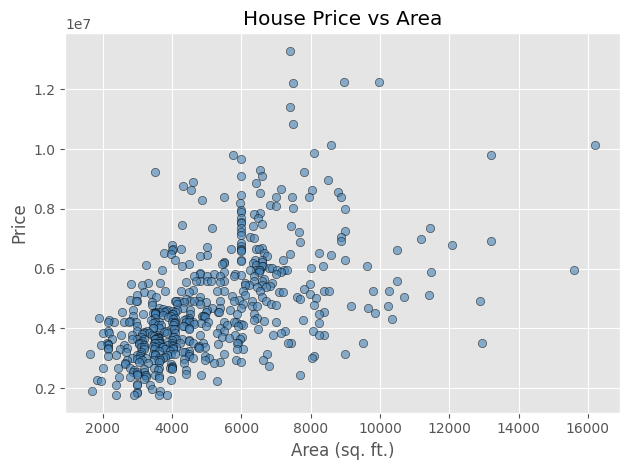

In [13]:
import matplotlib.pyplot as plt

plt.scatter(data['area'], data['price'], color='steelblue', alpha=0.6, edgecolor='k')
plt.title('House Price vs Area')
plt.xlabel('Area (sq. ft.)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

## Step 4: Train-Test Split

We split the data into training (80%) and testing (20%) sets.

In [14]:
from sklearn.model_selection import train_test_split

X = data[['area']]   # Feature (kept as 2D DataFrame for sklearn)
y = data['price']     # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print(X_train.head())
print(y_train.head())

Training samples: 425
Testing samples : 107
     area
306  4840
413  1950
458  3850
319  3000
145  5000
306    4165000
413    3430000
458    3115000
319    4060000
145    5600000
Name: price, dtype: int64


## Step 5: Train the Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 6: Slope and Intercept

For simple linear regression: `price = slope * area + intercept`

In [16]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (coefficient)  : {slope:.4f}")
print(f"Intercept             : {intercept:.4f}")
print(f"\nEquation: price = {slope:.4f} * area + ({intercept:.4f})")

Slope (coefficient)  : 441.5876
Intercept             : 2450352.7349

Equation: price = 441.5876 * area + (2450352.7349)


## Step 7: Accuracy Metrics

We evaluate the model on the **test set** using:
- **MAE** (Mean Absolute Error)
- **MSE** (Mean Squared Error)
- **RMSE** (Root Mean Squared Error)
- **R² Score** (coefficient of determination — how well the model explains variance in price)

In [17]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE)  : {mae:,.2f}")
print(f"Mean Squared Error (MSE)   : {mse:,.2f}")
print(f"Root Mean Squared Error    : {rmse:,.2f}")
print(f"R² Score                   : {r2:.4f}")

Mean Absolute Error (MAE)  : 1,424,905.44
Mean Squared Error (MSE)   : 3,547,685,936,845.33
Root Mean Squared Error    : 1,883,530.18
R² Score                   : 0.2770


## Step 8: Visualize the Regression Line

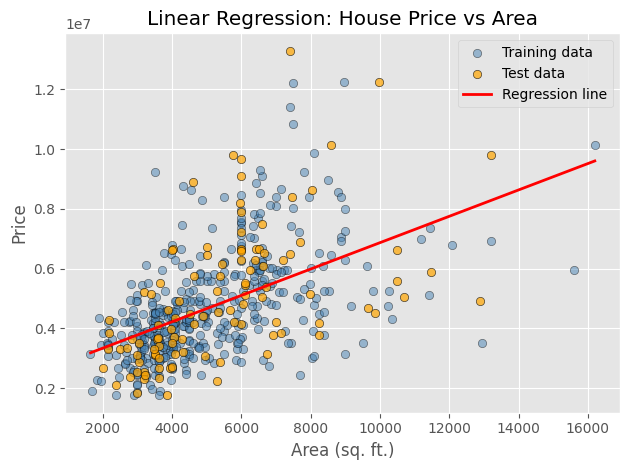

In [18]:
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, edgecolor='k', label='Training data')
plt.scatter(X_test, y_test, color='orange', alpha=0.7, edgecolor='k', label='Test data')

# Regression line across the full range of area values
x_range = np.linspace(data['area'].min(), data['area'].max(), 100).reshape(-1, 1)
y_range_pred = model.predict(pd.DataFrame(x_range, columns=['area']))

plt.plot(x_range, y_range_pred, color='red', linewidth=2, label='Regression line')

plt.title('Linear Regression: House Price vs Area')
plt.xlabel('Area (sq. ft.)')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Predict Price for a New House

Use the trained model to predict the price of a house given its area.

In [19]:
def predict_price(area_value):
    """Predict house price given an area (in sq. ft.) using the trained model."""
    input_df = pd.DataFrame([[area_value]], columns=['area'])
    predicted_price = model.predict(input_df)[0]
    return predicted_price

# Example usage
new_area = 3000   # change this value to any area you want to test
predicted = predict_price(new_area)
print(f"Predicted price for area = {new_area} sq. ft. : {predicted:,.2f}")

Predicted price for area = 3000 sq. ft. : 3,775,115.53


---
### Summary
- Trained a simple linear regression model on `area` → `price`.
- Reported slope, intercept, and evaluation metrics (MAE, MSE, RMSE, R²).
- Visualized both the raw data and the fitted regression line.
- Provided a reusable `predict_price()` function for new predictions.